In [1]:
import numpy as np
import scipy.stats as si
import scipy.interpolate as interpolate
import matplotlib.pyplot as plt
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
class GarmanKohlhagen:
    """
    Implémentation du pricer d'options FX (Modèle Garman-Kohlhagen).
    """
    def __init__(self, S, K, rd, rf, T, sigma):
        self.S = S
        self.K = K
        self.rd = rd
        self.rf = rf
        self.T = T
        self.sigma = sigma
        
        # Calcul de d1 et d2
        if self.T > 0:
            self.d1 = (np.log(self.S / self.K) + (self.rd - self.rf + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
            self.d2 = self.d1 - self.sigma * np.sqrt(self.T)
        else:
            self.d1 = np.inf if self.S >= self.K else -np.inf
            self.d2 = np.inf if self.S >= self.K else -np.inf

    def price(self, option_type='call'):
        """Calcule le prix de l'option."""
        if self.T == 0:
            if option_type.lower() == 'call':
                return max(0.0, self.S - self.K)
            else:
                return max(0.0, self.K - self.S)
                
        if option_type.lower() == 'call':
            return self.S * np.exp(-self.rf * self.T) * si.norm.cdf(self.d1) - self.K * np.exp(-self.rd * self.T) * si.norm.cdf(self.d2)
        elif option_type.lower() == 'put':
            return self.K * np.exp(-self.rd * self.T) * si.norm.cdf(-self.d2) - self.S * np.exp(-self.rf * self.T) * si.norm.cdf(-self.d1)
        else:
            raise ValueError("Le type d'option doit être 'call' ou 'put'")

    def greeks(self):
        """Calcule les sensibilités de premier et second ordre."""
        if self.T == 0:
            return {key: 0.0 for key in ['delta_call', 'delta_put', 'gamma', 'vega', 'theta_call', 'theta_put', 'rho_call', 'rho_put']}
            
        N_d1 = si.norm.cdf(self.d1)
        N_minus_d1 = si.norm.cdf(-self.d1)
        n_d1 = si.norm.pdf(self.d1)
        
        N_d2 = si.norm.cdf(self.d2)
        N_minus_d2 = si.norm.cdf(-self.d2)

        # Deltas
        delta_call = np.exp(-self.rf * self.T) * N_d1
        delta_put = -np.exp(-self.rf * self.T) * N_minus_d1
        
        # Gamma 
        gamma = (n_d1 * np.exp(-self.rf * self.T)) / (self.S * self.sigma * np.sqrt(self.T))
        
        # Vega 
        vega = self.S * np.sqrt(self.T) * np.exp(-self.rf * self.T) * n_d1
        
        # Theta
        term1 = -(self.S * self.sigma * np.exp(-self.rf * self.T) * n_d1) / (2 * np.sqrt(self.T))
        theta_call = term1 + self.rf * self.S * np.exp(-self.rf * self.T) * N_d1 - self.rd * self.K * np.exp(-self.rd * self.T) * N_d2
        theta_put = term1 - self.rf * self.S * np.exp(-self.rf * self.T) * N_minus_d1 + self.rd * self.K * np.exp(-self.rd * self.T) * N_minus_d2
        
        # Rho
        rho_call = self.K * self.T * np.exp(-self.rd * self.T) * N_d2
        rho_put = -self.K * self.T * np.exp(-self.rd * self.T) * N_minus_d2

        return {
            'delta_call': delta_call, 'delta_put': delta_put,
            'gamma': gamma, 'vega': vega / 100, 
            'theta_call': theta_call / 365, 'theta_put': theta_put / 365,
            'rho_call': rho_call / 100, 'rho_put': rho_put / 100
        }

In [3]:
class FXVolSurface:
    """
    Construction d'une surface de volatilité locale (Bid/Ask) à partir des cotations de marché FX.
    """
    def __init__(self, spot, rd, rf, market_data, bid_ask_spread_bps=15):
        self.spot = spot
        self.rd = rd
        self.rf = rf
        self.market_data = market_data # Dictionnaire {Maturity_in_years: {'ATM': v, '25RR': v, '25BF': v}}
        self.spread = bid_ask_spread_bps / 10000.0 # Spread de liquidité
        
        self.tenors = sorted(list(self.market_data.keys()))
        self.smile_interpolators_mid = {}
        self.smile_interpolators_bid = {}
        self.smile_interpolators_ask = {}
        
        self._build_surface()

    def _delta_to_strike(self, delta, tenor, vol, is_call):
        """
        Conversion d'un Delta FX en Strike.
        """
        phi = 1 if is_call else -1
        # Inversion de la formule du delta pour trouver K
        # Delta = phi * exp(-rf * T) * N(phi * d1)
        target_N = delta / np.exp(-self.rf * tenor)
        if target_N >= 1.0 or target_N <= 0.0:
            return self.spot # Fallback sécurité
            
        d1 = phi * si.norm.ppf(target_N)
        # d1 = [ln(S/K) + (rd - rf + vol^2/2)T] / (vol*sqrt(T))
        # K = S * exp(-d1*vol*sqrt(T) + (rd - rf + vol^2/2)T)
        K = self.spot * np.exp(-d1 * vol * np.sqrt(tenor) + (self.rd - self.rf + 0.5 * vol**2) * tenor)
        return K

    def _build_surface(self):
        """Construction des fonctions d'interpolation (Splines) pour chaque maturité."""
        for T in self.tenors:
            data = self.market_data[T]
            vol_atm = data['ATM']
            rr = data['25RR']
            bf = data['25BF']
            
            # Reconstruction des volatilités du Smile (Mid)
            vol_25c = vol_atm + bf + 0.5 * rr
            vol_25p = vol_atm + bf - 0.5 * rr
            
            # Conversion en Strikes
            k_atm = self.spot * np.exp((self.rd - self.rf) * T)
            k_25p = self._delta_to_strike(0.25, T, vol_25p, is_call=False)
            k_25c = self._delta_to_strike(0.25, T, vol_25c, is_call=True)
            
            strikes = np.array([k_25p, k_atm, k_25c])
            vols_mid = np.array([vol_25p, vol_atm, vol_25c])
            
            # Trier pour la spline 
            sort_idx = np.argsort(strikes)
            strikes = strikes[sort_idx]
            vols_mid = vols_mid[sort_idx]
            
            # Application du spread de liquidité
            liquidity_multiplier = np.array([1.5, 1.0, 1.5]) 
            vols_bid = vols_mid - (self.spread * liquidity_multiplier)
            vols_ask = vols_mid + (self.spread * liquidity_multiplier)
            
            # Interpolation par Spline Cubique
            self.smile_interpolators_mid[T] = interpolate.CubicSpline(strikes, vols_mid, bc_type='natural')
            self.smile_interpolators_bid[T] = interpolate.CubicSpline(strikes, vols_bid, bc_type='natural')
            self.smile_interpolators_ask[T] = interpolate.CubicSpline(strikes, vols_ask, bc_type='natural')

    def get_volatility(self, K, T, quote_type='mid'):
        """Interpolation 2D : Sur les strikes (Spline) puis linéaire sur le temps."""
        if quote_type == 'mid':
            interp_dict = self.smile_interpolators_mid
        elif quote_type == 'bid':
            interp_dict = self.smile_interpolators_bid
        else:
            interp_dict = self.smile_interpolators_ask

        # Si T est exact
        if T in self.tenors:
            return float(interp_dict[T](K))
            
        # Extrapolation plate temporelle
        if T < self.tenors[0]:
            return float(interp_dict[self.tenors[0]](K))
        if T > self.tenors[-1]:
            return float(interp_dict[self.tenors[-1]](K))
            
        # Interpolation linéaire de la variance dans le temps entre T1 et T2
        t1 = max([t for t in self.tenors if t <= T])
        t2 = min([t for t in self.tenors if t > T])
        
        vol1 = float(interp_dict[t1](K))
        vol2 = float(interp_dict[t2](K))
        
        var1 = (vol1**2) * t1
        var2 = (vol2**2) * t2
        var_interp = var1 + (var2 - var1) * (T - t1) / (t2 - t1)
        
        return np.sqrt(var_interp / T)

Test du Pricer Garman-Kohlhagen (Spot=1.10, Strike=1.12, T=1an, Vol=9%)
Prix du Call : 0.0366 USD
Delta Call   : 0.4872
Gamma        : 3.8909
Vega         : 0.0042



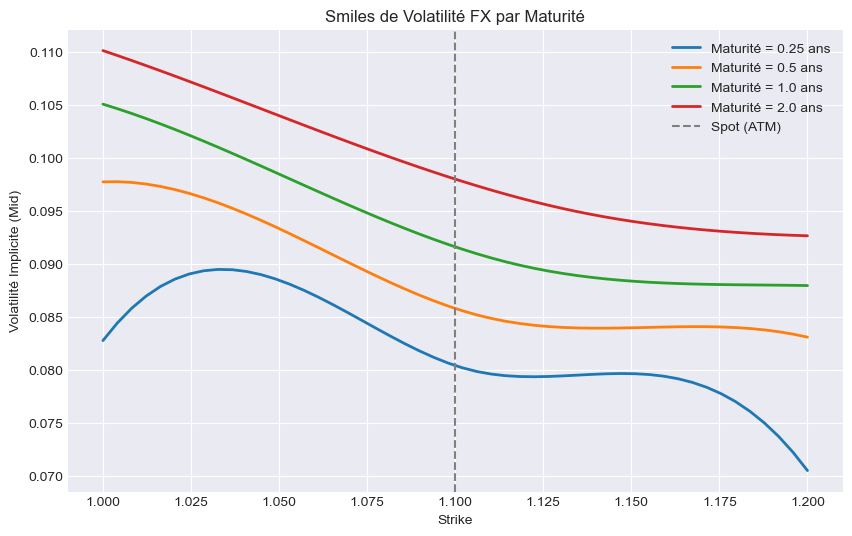

In [4]:
# 1. Données de marché FX (Exemple: EUR/USD)
spot_eurusd = 1.1000
rd_usd = 0.05
rf_eur = 0.035

# Format: {Maturité (années): {'ATM': vol, '25RR': vol, '25BF': vol}}
market_quotes = {
    0.25: {'ATM': 0.080, '25RR': -0.005, '25BF': 0.0020}, # Skew négatif
    0.50: {'ATM': 0.085, '25RR': -0.007, '25BF': 0.0025},
    1.00: {'ATM': 0.090, '25RR': -0.010, '25BF': 0.0030},
    2.00: {'ATM': 0.095, '25RR': -0.012, '25BF': 0.0035}
}

# Test du pricer
print("Test du Pricer Garman-Kohlhagen (Spot=1.10, Strike=1.12, T=1an, Vol=9%)")
pricer = GarmanKohlhagen(S=spot_eurusd, K=1.12, rd=rd_usd, rf=rf_eur, T=1.0, sigma=0.09)
call_price = pricer.price('call')
greeks = pricer.greeks()

print(f"Prix du Call : {call_price:.4f} USD")
print(f"Delta Call   : {greeks['delta_call']:.4f}")
print(f"Gamma        : {greeks['gamma']:.4f}")
print(f"Vega         : {greeks['vega']:.4f}\n")


surface = FXVolSurface(spot=spot_eurusd, rd=rd_usd, rf=rf_eur, market_data=market_quotes, bid_ask_spread_bps=20)


strikes_grid = np.linspace(0.95, 1.25, 30)
maturities_grid = np.linspace(0.25, 2.0, 30)
K_mesh, T_mesh = np.meshgrid(strikes_grid, maturities_grid)

Vol_Mid_mesh = np.zeros_like(K_mesh)
Vol_Bid_mesh = np.zeros_like(K_mesh)
Vol_Ask_mesh = np.zeros_like(K_mesh)

for i in range(K_mesh.shape[0]):
    for j in range(K_mesh.shape[1]):
        Vol_Mid_mesh[i, j] = surface.get_volatility(K_mesh[i, j], T_mesh[i, j], 'mid')
        Vol_Bid_mesh[i, j] = surface.get_volatility(K_mesh[i, j], T_mesh[i, j], 'bid')
        Vol_Ask_mesh[i, j] = surface.get_volatility(K_mesh[i, j], T_mesh[i, j], 'ask')


fig = go.Figure()


fig.add_trace(go.Surface(z=Vol_Ask_mesh, x=K_mesh, y=T_mesh, colorscale='Reds', opacity=0.7, name='Ask Surface', showscale=False))


fig.add_trace(go.Surface(z=Vol_Mid_mesh, x=K_mesh, y=T_mesh, colorscale='Viridis', name='Mid Surface'))


fig.add_trace(go.Surface(z=Vol_Bid_mesh, x=K_mesh, y=T_mesh, colorscale='Greens', opacity=0.7, name='Bid Surface', showscale=False))

fig.update_layout(
    title='Surface de Volatilité FX (Bid / Mid / Ask)',
    scene=dict(
        xaxis_title='Strike (K)',
        yaxis_title='Maturité (Années)',
        zaxis_title='Volatilité Implicite',
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.5))
    ),
    width=900, height=700,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()


plt.figure(figsize=(10, 6))
strikes_smile = np.linspace(1.0, 1.20, 50)
for T in market_quotes.keys():
    vols_t = [surface.get_volatility(k, T, 'mid') for k in strikes_smile]
    plt.plot(strikes_smile, vols_t, label=f'Maturité = {T} ans', lw=2)

plt.axvline(x=spot_eurusd, color='grey', linestyle='--', label='Spot (ATM)')
plt.title('Smiles de Volatilité FX par Maturité')
plt.xlabel('Strike')
plt.ylabel('Volatilité Implicite (Mid)')
plt.legend()
plt.show()